# Starting Masked Auto Encoders

* Now we try to understand this aspect of self-supervised learning with a simple masked image model.                                                                                                                              
                                                                                                                                                                                     
  1. Take an image, mask out a large percentage of patches (75% for MAE)                                                                                                             
  2. Feed only the visible patches into the encoder                                                                                                                                  
  3. Train a decoder to reconstruct the masked patches

Reading:
  - MAE: https://arxiv.org/abs/2111.06377
  - SimMIM: https://arxiv.org/abs/2111.09886

In [1]:
from vit import PatchEmbedding, TransformerEncoder

From the MAE paper:

* Main idea, mask a high percentage of the patches from an image and train a model to reconstruct the missing patches in pixel space. 

* If it can do that well, you have a sclabale vision learner.

Steps:

- 1. We use the same approach to patching as our vanilla ViT. Project that into emebddings given a hidden_dim. 
- 2. Mask patches. We randomly choose 75% of the patches, and remove them entirely from the sequence we have. We only pass the encoder the remaining 25% of the patches. (this makes training much faster)
- 3. Run visible patches through transformer encoder. This can be the same as our vanilla ViT Encoder. 
- 4. Take encoder outputs, and put them back in original positions. The masked positions withh now have a shared learnable mask token. We add positional embeddings back to full grid of patches. 
- 5. Decoder: run the full grid of masked and un-maksed tokens through a decoder. This will be a few transformer blocks and the task is to predict original pixels on the masked patches.
- 6. Caluclate the loss. MSE between decoders' outputs and actual pixel values form the masked patches. 

This is a recipe for pretraining. When it comes to fine-tuning, they just get the cnoder and a classification head. 

## Decoder

* How does a decoder to predict pixels actually work? 

In [6]:
import matplotlib.pyplot as plt                                                                                                           
import torch    
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100


import torch.nn.functional as F # This gives us the softmax()
import math                                                                                                                          
                                                                                                                                        
# Take a real image patch from your data
transform = transforms.Compose([                                                                                                          
    transforms.Resize((56, 56)),
    transforms.ToTensor(),  # values in [0, 1]
])

train_dataset_raw = CIFAR100(root='./data', train=True, download=True, transform=transform)
img, label = train_dataset_raw[0]  # [3, 56, 56]

Label: 19 → cattle


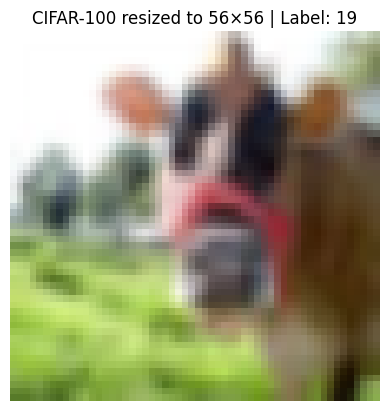

In [10]:
plt.imshow(img.permute(1, 2, 0))  # [3, 56, 56] -> [56, 56, 3]                                                                            
plt.title(f"CIFAR-100 resized to 56×56 | Label: {label}")                                                                                 
plt.axis('off')      
class_names = train_dataset_raw.classes  # list of 100 class names                                                                        
print(f"Label: {label} → {class_names[label]}")                                                                                                                     
plt.show()                                                                                                                                
             

In [20]:
patch = img[:, 49:56, 49:56]  # [3, 7, 7]
print("Patch shape:", patch.shape)
print("Pixel value range:", patch.min().item(), "to", patch.max().item())

Patch shape: torch.Size([3, 7, 7])
Pixel value range: 0.007843137718737125 to 0.6784313917160034


In [21]:
patch_flat = patch.reshape(-1)  # [147]
print("Flattened patch (decoder target):", patch_flat.shape)
# so the decoder must predict these 147 values

Flattened patch (decoder target): torch.Size([147])


In [22]:
patch_flat

tensor([0.3569, 0.2863, 0.2196, 0.2510, 0.2863, 0.3098, 0.3255, 0.2980, 0.2235,
        0.1725, 0.2196, 0.2706, 0.2941, 0.3098, 0.2314, 0.1569, 0.1255, 0.1922,
        0.2588, 0.2824, 0.2980, 0.1961, 0.1294, 0.1059, 0.2118, 0.3255, 0.3882,
        0.4275, 0.1647, 0.1059, 0.0941, 0.2392, 0.3922, 0.4902, 0.5529, 0.1373,
        0.0980, 0.1137, 0.2588, 0.4078, 0.4941, 0.5451, 0.1216, 0.0941, 0.1294,
        0.2745, 0.4196, 0.4941, 0.5412, 0.2980, 0.2235, 0.1608, 0.1961, 0.2431,
        0.2824, 0.3020, 0.2471, 0.1686, 0.1176, 0.1725, 0.2431, 0.2784, 0.2980,
        0.1922, 0.1137, 0.0745, 0.1569, 0.2471, 0.2824, 0.3020, 0.1608, 0.0902,
        0.0667, 0.2039, 0.3490, 0.4235, 0.4667, 0.1333, 0.0745, 0.0667, 0.2549,
        0.4549, 0.5647, 0.6353, 0.1098, 0.0745, 0.1098, 0.3020, 0.5020, 0.6000,
        0.6627, 0.0941, 0.0745, 0.1333, 0.3333, 0.5333, 0.6235, 0.6784, 0.1804,
        0.1137, 0.0549, 0.0627, 0.0824, 0.1059, 0.1176, 0.1216, 0.0627, 0.0275,
        0.0431, 0.0667, 0.0824, 0.0941, 

In [25]:
random_prediction = torch.rand(147)  # untrained decoder output
trained_prediction = patch_flat + torch.randn(147) * 0.05  # nearly trained decoder simulation, just the patch with noise

Loss (random): 0.1964
Loss (trained): 0.0024


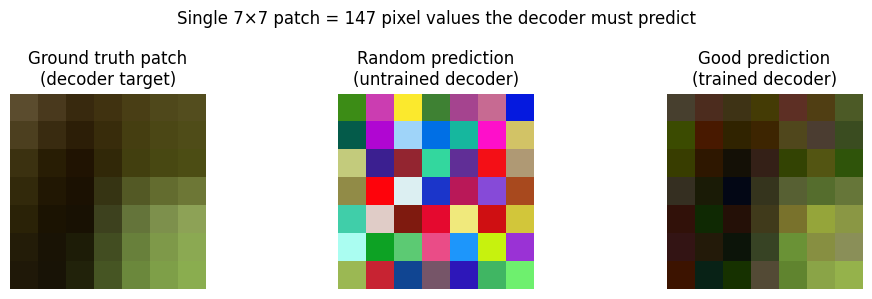

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(patch.permute(1, 2, 0))  # [H, W, C]
axes[0].set_title("Ground truth patch\n(decoder target)")

axes[1].imshow(random_prediction.reshape(3, 7, 7).permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("Random prediction\n(untrained decoder)")

axes[2].imshow(trained_prediction.reshape(3, 7, 7).permute(1, 2, 0).clamp(0, 1))
axes[2].set_title("Good prediction\n(trained decoder)")

for ax in axes:
    ax.axis('off')

plt.suptitle(f"Single 7×7 patch = {147} pixel values the decoder must predict")
plt.tight_layout()
print(f"Loss (random): {F.mse_loss(random_prediction, patch_flat):.4f}")
print(f"Loss (trained): {F.mse_loss(trained_prediction, patch_flat):.4f}")
plt.show()

## Ok, lets build it out

In [177]:
from vit import TransformerBlock

In [337]:
import numpy as np

class PredictPixel(nn.Module):
    def __init__(self, decoder_hidden_dim, patch_size,  mask_ratio = .75):
          super().__init__()
          self.decoder_hidden_dim = decoder_hidden_dim
          self.patch_size = patch_size
          self.ll = nn.Linear(decoder_hidden_dim, patch_size * patch_size * 3)

    def forward(self, x):
        """
        Decoder gives us one vetor per patch position.
        Each patch is 7x7x3. So each patch has 147 pixel values. 
        """
        x = self.ll(x)
        return x
    
class Mask(nn.Module):
    def __init__(self, mask_ratio = .75):
          super().__init__()
          self.mask_ratio = mask_ratio

    def forward(self, x):
      num_patches = x.shape[1]
      perm = torch.randperm(num_patches)
      masked_locations = perm[:int(num_patches * 0.75)]
      un_masked_locations  = perm[int(num_patches * 0.75):]            
      

      masked_patches = x[:, masked_locations, :]  # shape: [2, 48, 256]
      un_masked_patches = x[:, un_masked_locations, :]  # shape: [2, 48, 256]

      return un_masked_patches,  masked_patches, masked_locations, un_masked_locations
         

class Decoder(nn.Module):
      """
      Take the encoded patches that have not been masked and re-construct
      """
      def __init__(self, decoder_hidden_dim, hidden_dim, num_heads, depth, num_patches):
          super().__init__()
          self.decoder_hidden_dim = decoder_hidden_dim
          self.hidden_dim = hidden_dim
          self.num_heads = num_heads
          self.num_patches = num_patches
          self.project_down = nn.Linear(hidden_dim,decoder_hidden_dim )
          self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches , decoder_hidden_dim))
          self.mask_token = nn.Parameter(torch.randn(1, 1, decoder_hidden_dim))
          self.transformer_block = TransformerBlock(decoder_hidden_dim, num_heads, mlp_dim = decoder_hidden_dim*4)
          self.layers = nn.ModuleList(
              [TransformerBlock(decoder_hidden_dim, num_heads, mlp_dim = decoder_hidden_dim*4) for _ in range(depth)
          ])
      
      def forward(self, x, masked_locations, un_masked_locations):
          B, num_masked, _ = x.shape
          x = self.project_down(x)
          # now we need to create the full 64 patch tensors to feed that through the linear layer for pixel predictions
          mask_tokens = self.mask_token.expand(B, len(masked_locations), self.decoder_hidden_dim)
          full_sequence = torch.zeros(B, 64, self.decoder_hidden_dim, device = x.device)   
          full_sequence[:, un_masked_locations, :] = x          # projected encoder output
          full_sequence[:, masked_locations, :] = mask_tokens
          full_sequence = full_sequence + self.pos_embedding

          for block in self.layers:
              full_sequence = block(full_sequence)
          return full_sequence

* One thing I didnt know the differnce between `nn.Sequential` and `nn.ModuleList`

- nn.ModuleList is just a container — it stores modules but doesn't have a forward method. You can't call self.layers(x). 

- You can use nn.Sequential for the encode/decoder, but  ModuleList gives you more control (you can skip layers, add conditions, etc.), which is why most
  transformer implementations use it with a loop.

In [338]:
class MAE(nn.Module):
      def __init__(self, img_size, patch_size, num_hiddens, num_heads,mask_ratio,decoder_hidden_dim, depth=6, dropout=0.1):
          super().__init__()
          self.num_patches = (img_size // patch_size) ** 2
          self.mask_ratio = mask_ratio
          self.depth = depth
          self.patch_size = patch_size
        
          # --- Patch Embedding ---
          self.patch_embedding = PatchEmbedding(img_size, patch_size, num_hiddens)
        
          # -- maksing ###
          self.mask = Mask()
          # --- Positional Embedding (+1 for CLS) ---
          self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, num_hiddens))

          # --- Transformer Encoder ---
          self.encoder = TransformerEncoder(num_hiddens, depth, num_heads,  mlp_dim=num_hiddens*4)
          # --- Decoder ---
          self.decoder = Decoder(decoder_hidden_dim, num_hiddens, num_heads, depth, num_patches = self.num_patches)
          # picel predict
          self.pixel_head = PredictPixel(decoder_hidden_dim, self.patch_size)

      def forward(self, x):
        # 1. Patch embed: [B, 3, H, W] -> [B, num_patches, num_hiddens]
        patches = self.patch_embedding(x)
        patches = patches.flatten(2).transpose(1, 2)
        ## Mask 75% of input patches
        patches = patches + self.pos_embedding
        un_masked_patches, masked_patches, masked_locations, un_masked_locations = self.mask(patches)
        total_num_patches = len(masked_locations) + len(un_masked_locations)
        #   # 4. Transformer encoder
        x = self.encoder(un_masked_patches)
        #   decoder
        x = self.decoder(x,  masked_locations, un_masked_locations)
        x = self.pixel_head(x)
        return x  

In [339]:
img = torch.randn(2, 3, 56, 56)

In [340]:
mae_model = MAE(patch_size =7, num_hiddens=256, num_heads=8,mask_ratio=.75, decoder_hidden_dim = 128, img_size = 56)

In [341]:
out = mae_model(img)

In [342]:
out.shape

torch.Size([2, 64, 147])

In [343]:
# !pip install transformers

In [344]:
def visualize_mae(model, dataset, device, patch_size=7, img_size=56):    
      model.to(device)                                                                                                          
      model.eval()
      img, label = dataset[0]                                                                                                                                                        
      x = img.unsqueeze(0).to(device)  # [1, 3, 56, 56]

      with torch.no_grad():
          # Get patches and mask
          patches = model.patch_embedding(x)
          patches = patches.flatten(2).transpose(1, 2)
          patches = patches + model.pos_embedding
          un_masked_patches, masked_patches, masked_locations, un_masked_locations = model.mask(patches)

          # Encode and decode
          encoded = model.encoder(un_masked_patches)
          decoded = model.decoder(encoded, masked_locations, un_masked_locations)
          predicted = model.pixel_head(decoded)  # [1, 64, 147]

      # Build raw patches as target
      grid_size = img_size // patch_size
      raw_patches = img.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
      # [3, 8, 8, 7, 7] -> [64, 3, 7, 7]
      raw_patches = raw_patches.permute(1, 2, 0, 3, 4).reshape(-1, 3, patch_size, patch_size)

      # Reconstruct images
      pred_patches = predicted[0].cpu().reshape(-1, 3, patch_size, patch_size).clamp(0, 1)

      fig, axes = plt.subplots(1, 4, figsize=(20, 5))

      # 1. Original image
      axes[0].imshow(img.permute(1, 2, 0))
      axes[0].set_title("Original")

      # 2. Masked image (only visible patches shown)
      masked_img = torch.zeros_like(img)
      for idx in un_masked_locations:
          row = idx // grid_size
          col = idx % grid_size
          masked_img[:, row*patch_size:(row+1)*patch_size, col*patch_size:(col+1)*patch_size] = \
              img[:, row*patch_size:(row+1)*patch_size, col*patch_size:(col+1)*patch_size]
      axes[1].imshow(masked_img.permute(1, 2, 0))
      axes[1].set_title(f"Visible patches ({len(un_masked_locations)}/64)")

      # 3. Reconstruction (full)
      recon_img = torch.zeros(3, img_size, img_size)
      for i in range(grid_size * grid_size):
          row = i // grid_size
          col = i % grid_size
          recon_img[:, row*patch_size:(row+1)*patch_size, col*patch_size:(col+1)*patch_size] = \
              pred_patches[i]
      axes[2].imshow(recon_img.permute(1, 2, 0).clamp(0, 1))
      axes[2].set_title("Full reconstruction")

      # 4. Only masked patches reconstructed, visible patches from original
      mixed_img = img.clone()
      for idx in masked_locations:
          row = idx // grid_size
          col = idx % grid_size
          mixed_img[:, row*patch_size:(row+1)*patch_size, col*patch_size:(col+1)*patch_size] = \
              pred_patches[idx]
      axes[3].imshow(mixed_img.permute(1, 2, 0).clamp(0, 1))
      axes[3].set_title("Masked patches filled in")

      for ax in axes:
          ax.axis('off')
      plt.tight_layout()
      plt.show()

In [345]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using: {device}")

Using: mps


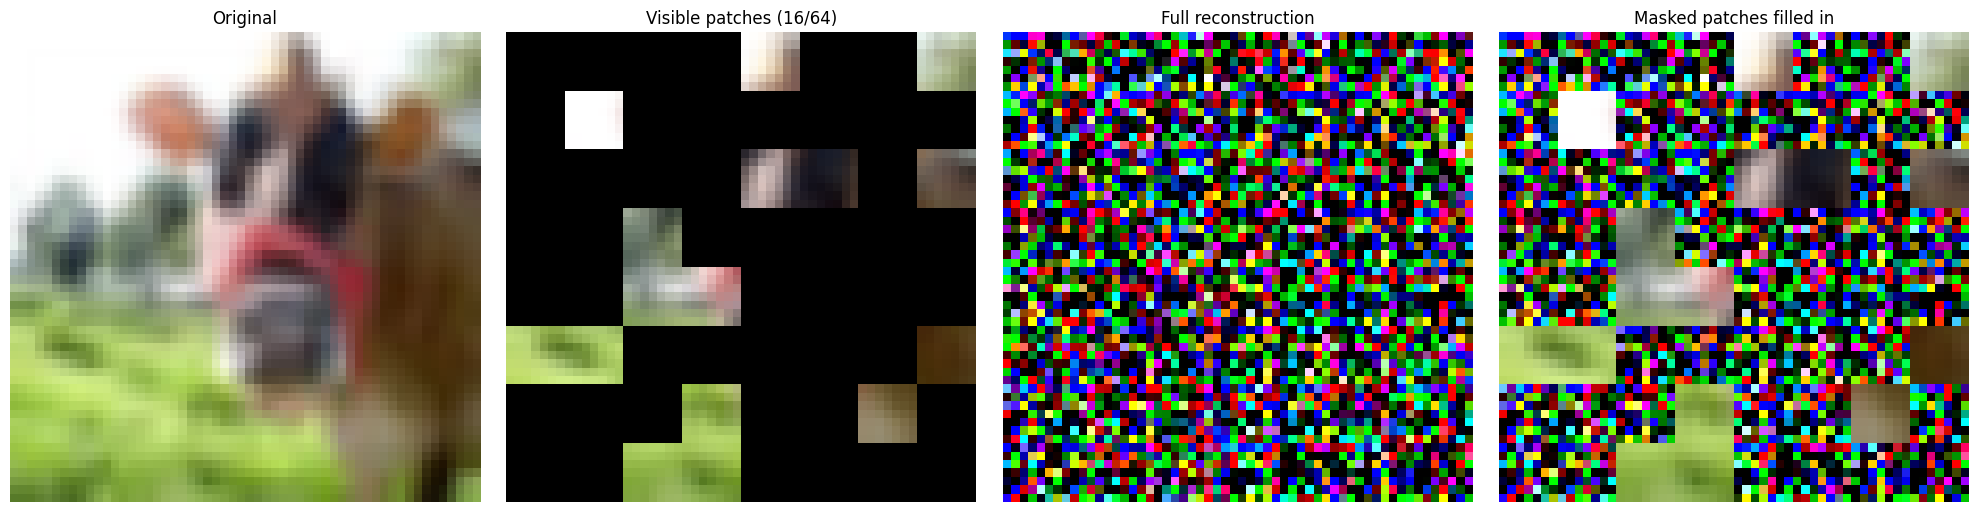

In [346]:
visualize_mae(mae_model, train_dataset_raw, device)

In [5]:
from transformers import ViTMAEModel, ViTMAEForPreTraining

model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")
print(model)

/Users/jpoberhauser/mambaforge3/envs/sam2_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 334/334 [00:00<00:00, 8620.75it/s]

ViTMAEForPreTraining(
  (vit): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): GELUActivat